In [4]:
import time
import re
import pandas as pd
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service as ChromeService
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager
from selenium.common.exceptions import NoSuchElementException # За справување со грешки

# --- 1. Поставување на Selenium WebDriver ---
options = Options()
options.add_argument("--headless")  # Работи во позадина
options.add_argument("--no-sandbox")
options.add_argument("--disable-dev-shm-usage")
service = ChromeService(ChromeDriverManager().install())
driver = webdriver.Chrome(service=service, options=options)

print("Selenium WebDriver е стартуван...")

all_book_data = [] # Листа за чување на сите податоци
base_url = "https://books.toscrape.com/catalogue/"
current_page_url = base_url + "page-1.html"

# --- 2. Главен циклус за навигација низ страници ---
while current_page_url:
    print(f"Обработувам страница: {current_page_url}")
    driver.get(current_page_url)
    
    # --- 3. Собирање на сите линкови од тековната страница ---
    book_elements = driver.find_elements(By.CSS_SELECTOR, "article.product_pod h3 a")
    book_links = [elem.get_attribute('href') for elem in book_elements]

    # --- 4. Наоѓање на следната страница ---
    try:
        next_page_relative_url = driver.find_element(By.CSS_SELECTOR, "li.next > a").get_attribute('href')
        current_page_url = next_page_relative_url # Selenium автоматски ќе го реши целиот URL
    except NoSuchElementException:
        current_page_url = None # Нема копче "next", ова е последната страница
        print("Стигнавме до последната страница.")
    # --- 5. Циклус за посета на секоја книга ---
    for book_url in book_links:
        driver.get(book_url)
        book_details = {} # Речник за деталите на оваа книга
        
        try:
            # Користиме try-except блокови за секој податок, 
            # за да не "падне" скриптата ако некој податок недостасува
            try:
                book_details['title'] = driver.find_element(By.CSS_SELECTOR, "div.product_main h1").text
            except NoSuchElementException:
                book_details['title'] = None
                
            try:
                book_details['price_raw'] = driver.find_element(By.CSS_SELECTOR, "p.price_color").text
            except NoSuchElementException:
                book_details['price_raw'] = None
                
            try:
                # Ова е важно: "In stock (19 available)"
                book_details['availability_raw'] = driver.find_element(By.CSS_SELECTOR, "p.instock.availability").text
            except NoSuchElementException:
                book_details['availability_raw'] = None
            
            try:
                # "star-rating Three"
                book_details['rating_raw'] = driver.find_element(By.CSS_SELECTOR, "p.star-rating").get_attribute("class")
            except NoSuchElementException:
                book_details['rating_raw'] = None
                
            try:
                book_details['category'] = driver.find_element(By.CSS_SELECTOR, "ul.breadcrumb li:nth-child(3) a").text
            except NoSuchElementException:
                book_details['category'] = None

            try:
                book_details['description'] = driver.find_element(By.CSS_SELECTOR, "div#product_description + p").text
            except NoSuchElementException:
                book_details['description'] = None
            
            # --- Екстракција на податоци од табелата ---
            table_rows = driver.find_elements(By.CSS_SELECTOR, "table.table-striped tr")
            book_details['upc'] = table_rows[0].find_element(By.TAG_NAME, "td").text
            book_details['price_excl_tax_raw'] = table_rows[2].find_element(By.TAG_NAME, "td").text
            book_details['price_incl_tax_raw'] = table_rows[3].find_element(By.TAG_NAME, "td").text
            book_details['tax_raw'] = table_rows[4].find_element(By.TAG_NAME, "td").text
            book_details['reviews_raw'] = table_rows[6].find_element(By.TAG_NAME, "td").text
            
            all_book_data.append(book_details)
            
        except Exception as e:
            print(f"  !! Грешка при обработка на книга: {book_url} - {e}")
            
    

# --- 6. Затворање на прелистувачот и креирање DataFrame ---
driver.quit()
print("WebDriver е затворен. Собрани се податоци за сите книги.")

df_all_books = pd.DataFrame(all_book_data)
print(f"Вкупно собрани книги: {len(df_all_books)}")
print(df_all_books.info())

Selenium WebDriver е стартуван...
Обработувам страница: https://books.toscrape.com/catalogue/page-1.html
Обработувам страница: https://books.toscrape.com/catalogue/page-2.html
Обработувам страница: https://books.toscrape.com/catalogue/page-3.html
Обработувам страница: https://books.toscrape.com/catalogue/page-4.html
Обработувам страница: https://books.toscrape.com/catalogue/page-5.html
Обработувам страница: https://books.toscrape.com/catalogue/page-6.html
Обработувам страница: https://books.toscrape.com/catalogue/page-7.html
Обработувам страница: https://books.toscrape.com/catalogue/page-8.html
Обработувам страница: https://books.toscrape.com/catalogue/page-9.html
Обработувам страница: https://books.toscrape.com/catalogue/page-10.html
Обработувам страница: https://books.toscrape.com/catalogue/page-11.html
Обработувам страница: https://books.toscrape.com/catalogue/page-12.html
Обработувам страница: https://books.toscrape.com/catalogue/page-13.html
Обработувам страница: https://books.tos

In [5]:
# Креираме копија за да го зачуваме оригиналот
df_clean = df_all_books.copy()

# 1. Чистење на Рејтинг
rating_map = {"One": 1, "Two": 2, "Three": 3, "Four": 4, "Five": 5}
# 'star-rating Three' -> 'Three' -> 3
df_clean['rating'] = df_clean['rating_raw'].str.split().str[1].map(rating_map)

# 2. Чистење на Достапност
# 'In stock (19 available)' -> '19' -> 19
df_clean['availability'] = df_clean['availability_raw'].str.extract(r'(\d+)').astype(int)

# 3. Чистење на Цени и Данок (користиме regex за броеви)
def extract_price(text):
    if text is None:
        return None
    match = re.search(r'([\d\.]+)', text)
    return float(match.group(0)) if match else None

df_clean['price'] = df_clean['price_raw'].apply(extract_price)
df_clean['price_excl_tax'] = df_clean['price_excl_tax_raw'].apply(extract_price)
df_clean['price_incl_tax'] = df_clean['price_incl_tax_raw'].apply(extract_price)
df_clean['tax'] = df_clean['tax_raw'].apply(extract_price)

# 4. Чистење на Рецензии
df_clean['reviews'] = df_clean['reviews_raw'].astype(int)

# 5. Избирање на финалните, чисти колони
final_columns = [
    'title', 'category', 'price', 'rating', 'availability', 
    'price_excl_tax', 'price_incl_tax', 'tax', 'reviews', 'upc', 'description'
]
df_final = df_clean[final_columns]

print("Податоците се исчистени. Приказ на првите 5 реда:")
print(df_final.head())
print("\nИнфо за исчистениот DataFrame:")
df_final.info()

Податоците се исчистени. Приказ на првите 5 реда:
                                   title            category  price  rating  \
0                   A Light in the Attic              Poetry  51.77       3   
1                     Tipping the Velvet  Historical Fiction  53.74       1   
2                             Soumission             Fiction  50.10       1   
3                          Sharp Objects             Mystery  47.82       4   
4  Sapiens: A Brief History of Humankind             History  54.23       5   

   availability  price_excl_tax  price_incl_tax  tax  reviews  \
0            22           51.77           51.77  0.0        0   
1            20           53.74           53.74  0.0        0   
2            20           50.10           50.10  0.0        0   
3            20           47.82           47.82  0.0        0   
4            20           54.23           54.23  0.0        0   

                upc                                        description  
0  a897fe39

--- Дескриптивни статистики за достапност на книгите ---
count    1000.000000
mean        8.585000
std         5.654622
min         1.000000
25%         3.000000
50%         7.000000
75%        14.000000
max        22.000000
Name: availability, dtype: float64
---------------------------------------------------------


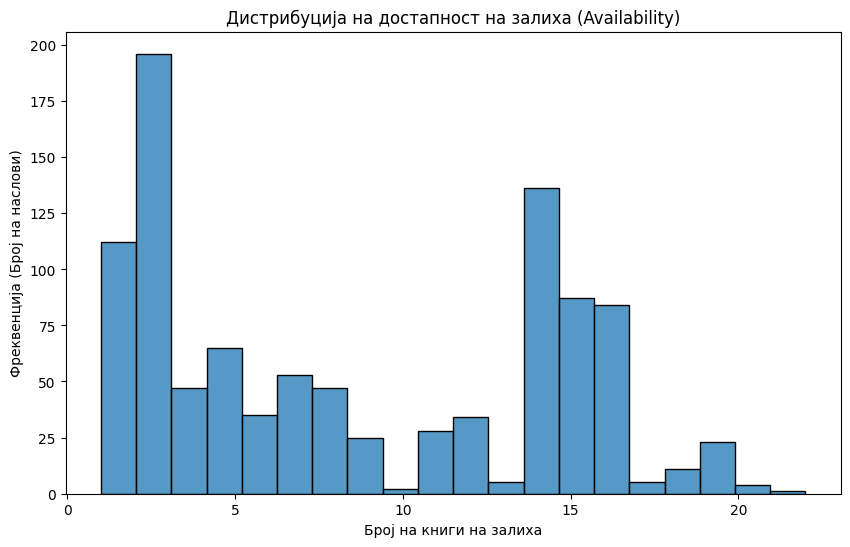

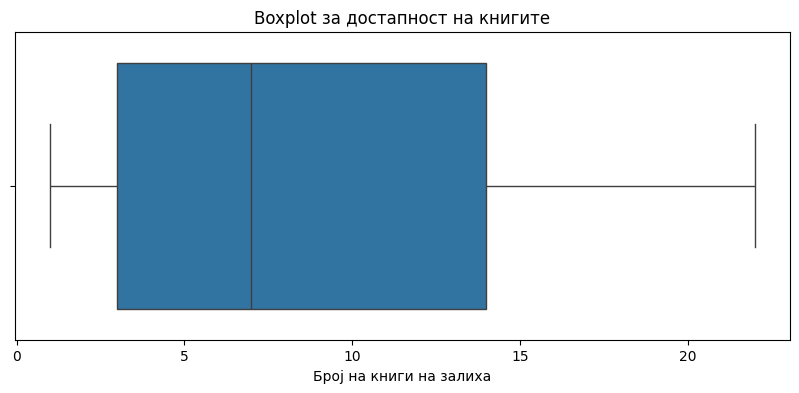

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Пресметка на дескриптивни статистики за достапноста
availability_stats = df_final['availability'].describe()

print("--- Дескриптивни статистики за достапност на книгите ---")
print(availability_stats)
print("---------------------------------------------------------")

# 2. (Опционално) Визуелизација на дистрибуцијата на достапноста
plt.figure(figsize=(10, 6))
sns.histplot(df_final['availability'], bins=20, kde=False)
plt.title('Дистрибуција на достапност на залиха (Availability)')
plt.xlabel('Број на книги на залиха')
plt.ylabel('Фреквенција (Број на наслови)')
plt.show()

# 3. (Опционално) Boxplot за подобар приказ на дистрибуцијата
plt.figure(figsize=(10, 4))
sns.boxplot(x=df_final['availability'])
plt.title('Boxplot за достапност на книгите')
plt.xlabel('Број на книги на залиха')
plt.show()